In [1]:
! git pull
import os, sys, pickle
from importlib import reload
%pylab inline
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 2.5)

Already up to date.
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [26]:
reload(os)
[g for g in list(os.environ.keys()) if g.startswith("GLOM")]

['GLOM_IO_DATA', 'GLOM_IO']

In [3]:
assert "GLOM_IO" in os.environ, "GLOM_IO environment variable not set"
proj_path = os.environ["GLOM_IO"]
assert os.path.exists(proj_path), f"Project path {proj_path} does not exist"
sys.path.append(proj_path)
sys.path.append(proj_path + "/model-fitting") 
sys.path.append(proj_path + "/analysis")

In [7]:
import compute; reload(compute)
from compute import free as compute_free
reload(compute.free)
free_data = compute_free.Data().compute()

COMPUTING free.Data.
Loading models from self.base_dir='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std'
stats_include_diag=True
Loading  190 records from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/ffree/collected.p...done (190/190 configs from in.*.p files). Loading config file: /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/ffree.yaml
Available stats for set train in model Free: ['r2', 'pearson', 'spearman', 'ratio']
Free
Best params: λ=3.16e+06
       train: 0.525 +/- 0.026
        test: 0.296 +/- 0.039
         vld: 0.276 +/- 0.057
Loaded outputs from out_file='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/ffree/out.9.p'
Loading data from /camp/home/tootoos/

/camp/home/tootoos/working/tootoos/git/ob_io_conn_models/models/free.py:151: OptimizeWarning: Unknown solver options: maxiter
  self.results = minimize(self.LOSS, p0, jac=self.JAC_LOSS, **kwargs)
  NIT   NF   F                       GTG
    0    1  7.476354389364516E+03   3.45586218E+08
tnc: fscale = 4.52332e-05
    1    5  3.609763625590079E+03   3.01297444E+06
    2   11  1.030779177787003E+03   7.72708373E+06
    3   14  7.939729076537833E+02   6.17981658E+05
tnc: fscale = 0.00115765
    4   22  6.345230005736797E+02   6.05039013E+05
    5   31  5.609867494232600E+02   3.49531091E+05
    6   36  5.225939282343165E+02   1.82754576E+05
    7   41  4.991919612810445E+02   1.97744133E+05
    8   48  4.814684478789578E+02   9.01170918E+04
    9   52  4.768475042257047E+02   1.71936973E+03
   10   58  4.748841204429681E+02   3.12214052E+03
   11   61  4.747544822414291E+02   4.88848017E+01
tnc: fscale = 0.129493
   12   68  4.746821219325874E+02   1.73303343E+00
   13   73  4.746797762782

Minimization finished with status 1.
Message: Converged (|f_n-f_(n-1)| ~= 0)
COV_LOSS at solution: 379.7971232411162
Loaded outputs from out_file='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/ffree/out.28.p'
Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Standardizing training, test and validation sets separately.
Normalizing input by odour.
Normalizing output by overall standard deviation.
Computing props for trial 1 with best_la=3.16e+06
Loaded outputs from out_file='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/ffree/out.47.p'
Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Standardizing training, test and validation sets separately.
Normalizing input by odour.
Normalizing output by ove

PLOTTING FIGURE FitFree
PLOTTING PANELS Schem
PLOTTING PANELS FreeReps
include_diag=False
PLOTTING PANELS FreeConn
PLOTTING PANELS FreeConnModes
PLOTTING PANELS FreeConnModesHist


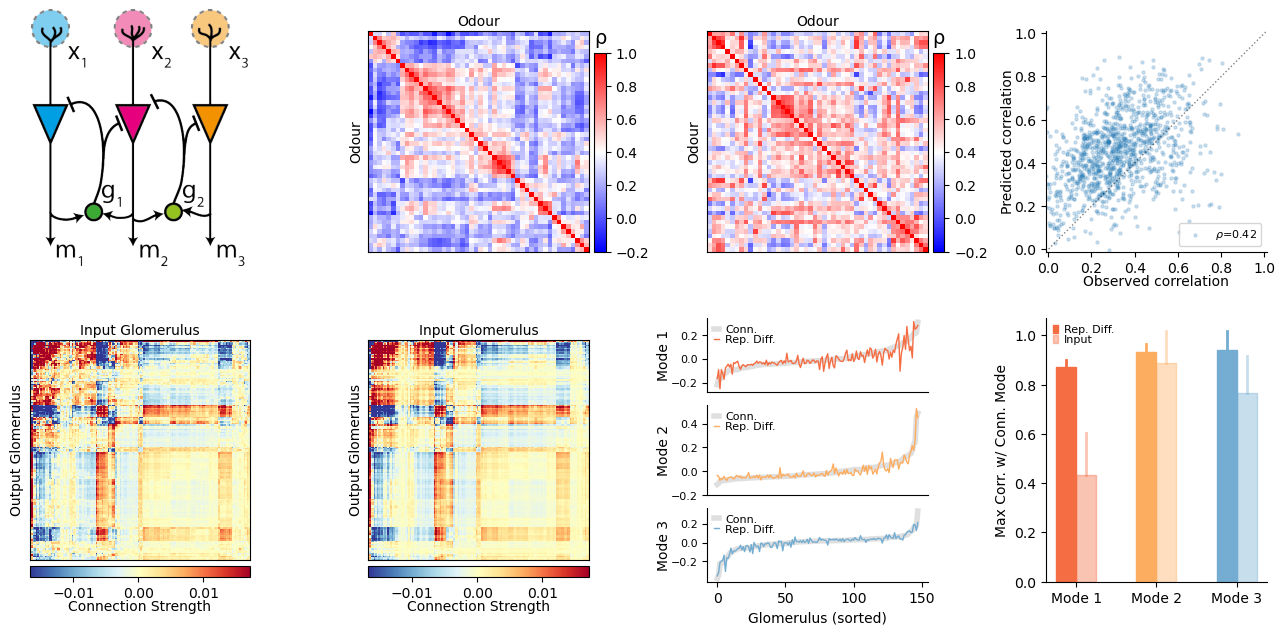

In [11]:
import figures as figures; reload(figures)
import figures.figures; reload(figures.figures)
from figures import free as fig_free; reload(figures.free)
from figures.figures import reduce_vertical_gaps 
fig = figure(figsize=(13, 6.5)); #title("HellO")
ax = fig_free.Main.plot(free_data)
tight_layout(h_pad=1., w_pad=0.5)
ax_vs = ax["fit_vs"]
ax_vs.set_xticks(arange(0, 1.1, 0.2))
ax_vs.set_yticks(arange(0, 1.1, 0.2))
ax_vs.set_xlabel("Observed correlation", labelpad=-0.5)
ax_vs.set_ylabel("Predicted correlation", labelpad=-0.5)
ax_modes = ax["modes"]
ax_hist = ax["hist"]
reduce_vertical_gaps(ax_modes, 0.1)

In [32]:
from compute import show_models as compute_show_models
reload(compute_show_models)
show_models_data = compute_show_models.Data().compute()

COMPUTING show_models.Data.
Loaded results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model_fitting/generalization_results.pkl.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


In [38]:
smd = show_models_data
[d for d in dir(smd.models["Diag"]["vld_corrs"]) if not d.startswith("_")]

TypeError: 'Extraction' object is not subscriptable

In [40]:
smd.models["Diag"].vld_corrs

{'Cin': array([[0.77264753, 0.79425793, 0.74703609, ..., 0.58200633, 0.52619181,
         0.38624958],
        [0.73345716, 0.6417718 , 0.72812223, ..., 0.57699443, 0.49532717,
         0.32876334],
        [0.62279374, 0.785958  , 0.74392635, ..., 0.64782807, 0.54002023,
         0.53919537],
        ...,
        [0.42095733, 0.49091303, 0.66723796, ..., 0.77875903, 0.77440526,
         0.47852459],
        [0.52774066, 0.47116466, 0.68075762, ..., 0.70869192, 0.82937038,
         0.46749399],
        [0.20999141, 0.34284666, 0.48069057, ..., 0.57947312, 0.53913   ,
         0.71019547]], shape=(48, 48)),
 'Cstar': array([[ 0.57143654,  0.35515592,  0.1074786 , ..., -0.01649483,
          0.38882379,  0.50890767],
        [ 0.31457666,  0.6526983 , -0.04040394, ...,  0.16130024,
          0.08791669,  0.29918038],
        [ 0.09724991, -0.07265529,  0.70399991, ...,  0.33202633,
          0.13783145,  0.1311403 ],
        ...,
        [ 0.00572634,  0.08731413,  0.29544281, ...,  0.60

PLOTTING FIGURE FitDiag
PLOTTING PANELS Schem
PLOTTING PANELS Schem


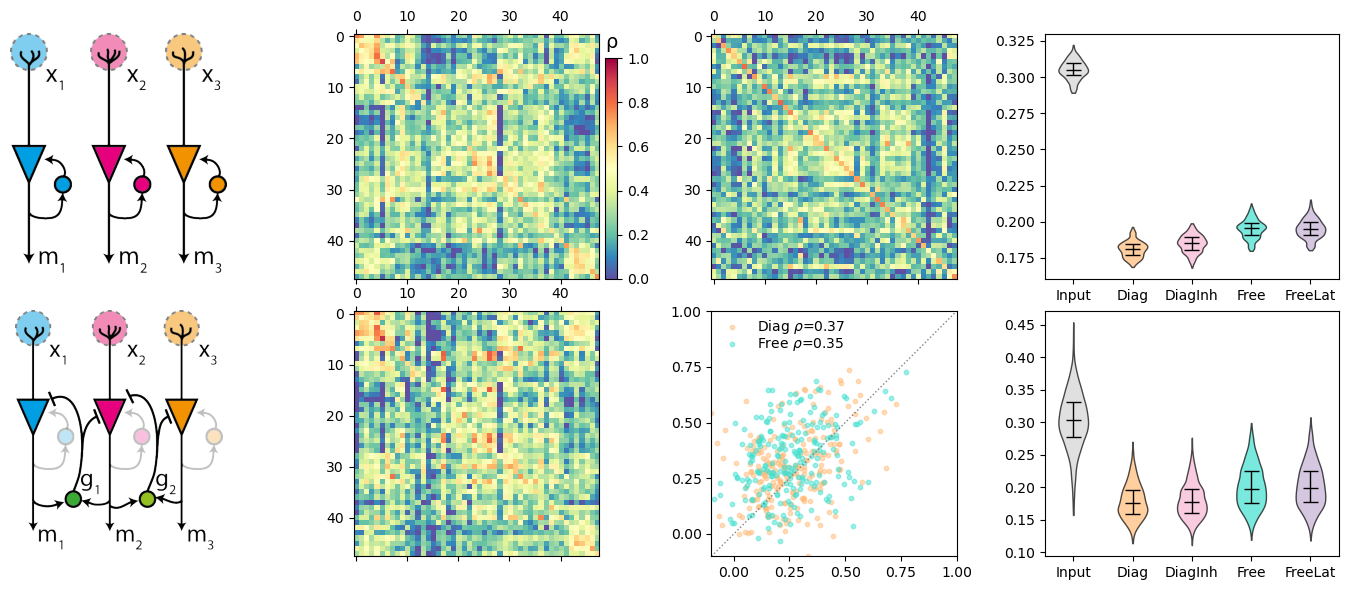

In [73]:
import analysis.figures; reload(analysis.figures)
from analysis.figures import figures as figures_figures; reload(figures_figures)
from analysis.figures import show_models as fig_show_models; reload(fig_show_models)
fig = figure(figsize=(14, 6)); #title("HellO")
ax = fig_show_models.Main.plot(show_models_data)#, free_corr_energy=free_data.corr_energy)
tight_layout(h_pad=0)

# Diag Figure

In [4]:
import proc_fit_models
reload(proc_fit_models)

<module 'proc_fit_models' from '/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/proc_fit_models.py'>

In [5]:
from compute import compute as compute2
import driver; reload(driver)
reload(compute2)
print(compute2.center)
from compute import diag as compute_diag
reload(compute_diag)
#diag_data = compute_diag.Data().compute(best_stat = "r2", best_stat_includes_diag = True, 
#                                                        corr_stats_include_diag = {
#                                                            "in-in":False,
#                                                            "in-out":False,
#                                                            "out-out":False,
#                                                            "model-out":True,
#                                                        }
#                                                        )

proj_path='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release'
fits_root='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting'
data_root='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data'
conn_models_path='/camp/home/tootoos/working/tootoos/git/ob_io_conn_models'
Adding parent
Loading  /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/analysis/compute/compute.py
Adding parent
Loading  /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/analysis/compute/compute.py
True


<module 'compute.diag' from '/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/analysis/compute/diag.py'>

PLOTTING FIGURE FitDiag
PLOTTING PANELS Schem
PLOTTING PANELS Schem


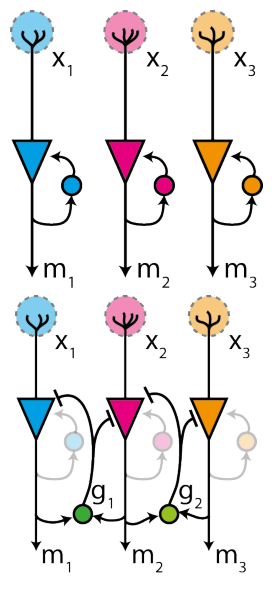

In [10]:
import analysis.figures; reload(analysis.figures)
from analysis.figures import figures as figures_figures; reload(figures_figures)
from analysis.figures import diag as fig_diag; reload(fig_diag)
fig = figure(figsize=(14, 6)); #title("HellO")
ax = fig_diag.Main.plot(None)#, free_corr_energy=free_data.corr_energy)
tight_layout(h_pad=0)

In [8]:
?figures

Object `figures` not found.
